![title](img/SupFig1.jpg)

# Supplementary Figure 1
Supplementary Figure 1. Mean wind stress curl over 1958-1978 for (a) FOSI, (b) LENS, (c) standard deviation across LENS ensemble members, and (d) the difference between FOSI and LENS.

### Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.colors as colors
import numpy as np
import cmocean
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

### Functions

In [38]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]

In [39]:
CESMLENS_var = afuncs.LENS_for_regridding()

In [60]:
LENS_mean_TEMP_depth = regridded_LENS_TEMP_depth.mean(dim='time')
LENS_TEMP_depth_1deg = proc_utils.regrid_SMYLE(LENS_mean_TEMP_depth)
regridded_LENS_TEMP_depth = regridder(LENS_TEMP_depth_1deg)

In [61]:
FOSI_mean_TEMP_depth = regridded_FOSI_TEMP_depth.mean(dim='time')
FOSI_TEMP_depth_1deg = proc_utils.regrid_SMYLE(FOSI_mean_TEMP_depth)
regridded_FOSI_TEMP_depth = regridder(FOSI_TEMP_depth_1deg)

In [62]:
diff = regridded_LENS_TEMP_depth - regridded_FOSI_TEMP_depth

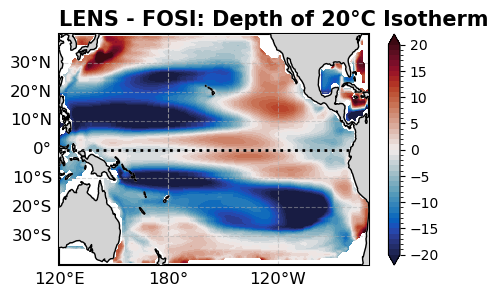

In [63]:
# LENS --------- Mean depth of 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

(diff.sel(lat=slice(-40, 40), lon=slice(120,290))/100).plot.contourf(
    vmin=-20, vmax=20, levels=41, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree(), add_colorbar=True)

plt.title('')
plt.title('LENS - FOSI: Depth of 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

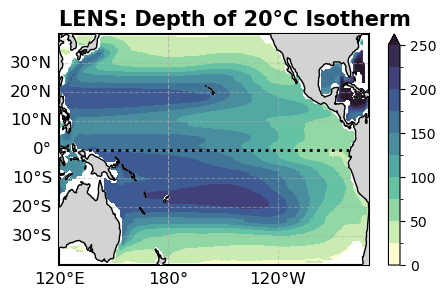

In [64]:
# LENS --------- Mean depth of 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')  # Override the equal aspect ratio

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}  # Longitude labels
gl.ylabel_style = {'size': 12}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

(regridded_LENS_TEMP_depth.sel(lat=slice(-40, 40), lon=slice(120,290))/100).plot.contourf(
    vmin=0, vmax=250, levels=11, cmap=cmocean.cm.deep, transform=ccrs.PlateCarree(), add_colorbar=True)

plt.title('')
plt.title('LENS: Depth of 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

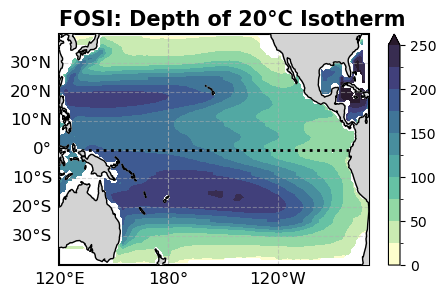

In [65]:
# FOSI --------- Mean depth of 20°C Isotherm
fig, ax = plt.subplots(figsize=(5, 3), 
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 290, -40, 40], crs=ccrs.PlateCarree())
ax.set_aspect('auto')

gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.axhline(y=0, color='k', linestyle='dotted', linewidth=2, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)

(regridded_FOSI_TEMP_depth.sel(lat=slice(-40, 40), lon=slice(120,290))/100).plot.contourf(
    vmin=0, vmax=250, levels=11, cmap=cmocean.cm.deep, transform=ccrs.PlateCarree(), add_colorbar=True)

plt.title('')
plt.title('FOSI: Depth of 20°C Isotherm', fontsize=15, fontweight='bold', zorder=12, loc='left')
plt.show()

In [23]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'ULONG': 'lon', 'ULAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

## TAUX

In [24]:
# LENS for regridding purposes
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

#### FOSI set up
firstyear = 1959
lastyear = 2020
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

In [25]:
field = 'TEMP'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
ds_smyle_fosi_var = xr.open_dataset(fpath+fname)[field]
ds_smyle_fosi_var['time'] = fosi_montime_vals
var_fosi = ds_smyle_fosi_var.isel(z_t = 0).compute()
fosi_1deg_wzeros_var = regrid_SMYLE(var_fosi)
fosi_1deg_var = fosi_1deg_wzeros_var.where(fosi_1deg_wzeros_var!=0, np.nan)

In [26]:
field = 'TAUX'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
ds_smyle_fosi_var = xr.open_dataset(fpath+fname)[field]
ds_smyle_fosi_var['time'] = fosi_montime_vals
var_fosi = ds_smyle_fosi_var.isel(time=slice(0, 240)).compute()
fosi_1deg_wzeros_var = regrid_SMYLE(var_fosi)
fosi_1deg_var = fosi_1deg_wzeros_var.where(fosi_1deg_wzeros_var!=0, np.nan)

In [27]:
%%time
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]
regridded_TAUX_lens_list = []
for ENS_MEMB in ensemble_members:
    print(ENS_MEMB)
    TAUX = afuncs.ocn_var_ens(ENS_MEMB, 'TAUX').isel(time=slice(0, 240)).mean(dim='time')
    lens_1deg_wzeros_var = regrid_SMYLE(TAUX)
    lens_1deg_var = lens_1deg_wzeros_var.where(lens_1deg_wzeros_var!=0, np.nan)
    regridder = xe.Regridder(fosi_1deg_var, CESMLENS_var[:,:,:], 'nearest_s2d', periodic=True)
    regridded_lens_TAUX = regridder(lens_1deg_var)
    regridded_TAUX_lens_list.append(regridded_lens_TAUX)

0
65
32
85
61
90
80
68
73
49
CPU times: user 35.9 s, sys: 2.25 s, total: 38.2 s
Wall time: 1min 37s


In [31]:
regridder = xe.Regridder(fosi_1deg_var, CESMLENS_var[:,:,:], 'nearest_s2d', periodic=True)
regridded_lens_TAUX = regridder(lens_1deg_var)
regridded_fosi_TAUX = regridder(fosi_1deg_var)
diff = regridded_lens_TAUX - regridded_fosi_TAUX.mean(dim='time')

In [32]:
ensemble_mean_TAUX_lens = xr.concat(regridded_TAUX_lens_list, dim='ensemble').mean(dim='ensemble')

In [33]:
ensemble_mean_TAUX_lens_comp = ensemble_mean_TAUX_lens.compute()

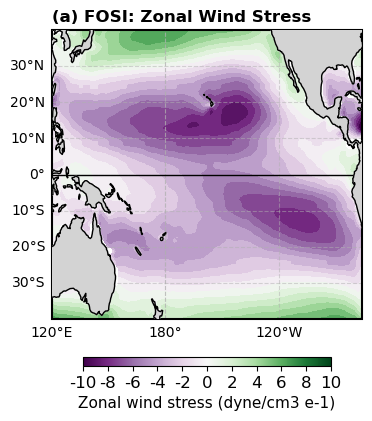

In [95]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
# ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_fosi_TAUX.mean(dim='time').plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-1, vmax=1, levels=21, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-10, 10))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('Zonal wind stress (dyne/cm3 e-1)', fontsize=11)
tick_values = np.arange(-10, 12, 2) 
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x:.0f}' for x in tick_values])

# density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=12)


plt.title('(a) FOSI: Zonal Wind Stress', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()

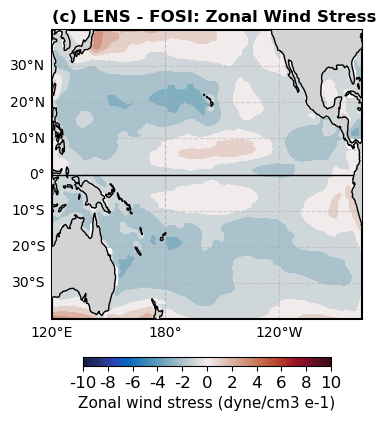

In [35]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = diff.plot.contourf(
    x='lon', y='lat', add_colorbar=False, transform=ccrs.PlateCarree(),cmap=cmocean.cm.balance,
    vmin=-1, vmax=1, 
    levels=21, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap=cmocean.cm.balance, norm=plt.Normalize(-10, 10))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('Zonal wind stress (dyne/cm3 e-1)', fontsize=11)
tick_values = np.arange(-10, 12, 2) 
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x:.0f}' for x in tick_values])

# density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=12)

plt.title('(c) LENS - FOSI: Zonal Wind Stress', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()

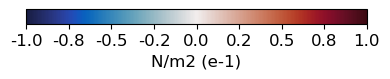

In [12]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 0.9))

# Balance colorbar  
density_sm2 = plt.cm.ScalarMappable(cmap=cmocean.cm.balance, norm=plt.Normalize(-1, 1))
cbar2 = plt.colorbar(density_sm2, cax=ax1, orientation='horizontal')
# cbar2.set_label('Transport (Sv/deg longitude)', fontsize=12)
cbar2.set_label('N/m2 (e-1)', fontsize=12)

tick_values2 = np.arange(-1, 1.1, 0.25)  # -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3
cbar2.set_ticks(tick_values2 * 1)
cbar2.set_ticklabels([f'{x:.01f}' for x in tick_values2])
cbar2.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [53]:
# diff = regridded_lens_TAUX - regridded_fosi_TAUX
diff = ensemble_mean_TAUX_lens - regridded_fosi_TAUX

In [ ]:
ensemble_mean_TAUX_lens = ensemble_mean_TAUX_lens.compute()

## Wind Stress Curl

In [33]:
import numpy as np
import xarray as xr
import xgcm
from matplotlib import pyplot as plt

import pop_tools

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)

In [34]:
field = 'TAUX'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
ds_smyle_fosi_var = xr.open_dataset(fpath+fname)
ds_smyle_fosi_var['time'] = fosi_montime_vals
TAUX = ds_smyle_fosi_var[field].isel(time=slice(0, 240)).mean(dim='time')

field = 'TAUY'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
ds_smyle_fosi_var = xr.open_dataset(fpath+fname)
ds_smyle_fosi_var['time'] = fosi_montime_vals
TAUY = ds_smyle_fosi_var[field].isel(time=slice(0, 240)).mean(dim='time')

In [35]:
def calculate_curl_simple(taux, tauy, dx, dy):
    """Calculate curl using centered finite differences"""
    # Assuming all arrays are on the same grid
    # Use numpy gradient
    dtauy_dx = np.gradient(tauy, axis=1) / dx
    dtaux_dy = np.gradient(taux, axis=0) / dy
    return dtauy_dx - dtaux_dy
    
# Convert to numpy arrays
variables_xr = xr.Dataset()
taux_np = TAUX.values
tauy_np = TAUY.values
dx_np = ds_smyle_fosi_var.DXU.values  # or DXT depending on grid
dy_np = ds_smyle_fosi_var.DYU.values  # or DYT depending on grid

# Calculate curl
curl_np = calculate_curl_simple(taux_np, tauy_np, dx_np, dy_np)

# Convert back to xarray
curl_simple = xr.DataArray(
    curl_np,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [36]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]
TAUX_lens_list=[]
for ENS_MEMB in ensemble_members:
    print(ENS_MEMB)
    TAUX = afuncs.ocn_var_ens(ENS_MEMB, 'TAUX').isel(time=slice(0, 240)).mean(dim='time')
    TAUX_lens_list.append(TAUX)

TAUY_lens_list=[]
for ENS_MEMB in ensemble_members:
    print(ENS_MEMB)
    TAUY = afuncs.ocn_var_ens(ENS_MEMB, 'TAUY').isel(time=slice(0, 240)).mean(dim='time')
    TAUY_lens_list.append(TAUY)

0
65
32
85
61
90
80
68
73
49
0
65
32
85
61
90
80
68
73
49


In [37]:
lens_TAUX_ds = xr.concat(TAUX_lens_list, dim='ensemble')
lens_TAUY_ds = xr.concat(TAUY_lens_list, dim='ensemble')

In [42]:
curl_simple_list = []
for ens_indx in range(10):
    print(ens_indx)
    TAUX_data = lens_TAUX_ds.isel(ensemble=ens_indx)
    TAUY_data = lens_TAUY_ds.isel(ensemble=ens_indx)

    # Convert to numpy arrays
    variables_xr = xr.Dataset()
    taux_np = TAUX_data.values
    tauy_np = TAUY_data.values
    dx_np = ds_smyle_fosi_var.DXU.values  # or DXT depending on grid
    dy_np = ds_smyle_fosi_var.DYU.values  # or DYT depending on grid
    
    # Calculate curl
    curl_np = calculate_curl_simple(taux_np, tauy_np, dx_np, dy_np)
    
    # Convert back to xarray
    curl_simple = xr.DataArray(
        curl_np,
        coords=TAUX.coords,
        dims=TAUX.dims,
        name='wind_stress_curl_simple'
    )
    curl_simple_list.append(curl_simple)

0
1
2
3
4
5
6
7
8
9


In [43]:
lens_curl_taux_ds = xr.concat(curl_simple_list, dim='ensemble')

In [48]:
diff_1deg_wzeros_var = regrid_SMYLE(lens_curl_taux_ds.std(dim='ensemble'))
diff_1deg_var = diff_1deg_wzeros_var.where(diff_1deg_wzeros_var!=0, np.nan)
regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[0,:,:], 'nearest_s2d', periodic=True)
regridded_lens_diff = regridder(diff_1deg_var)

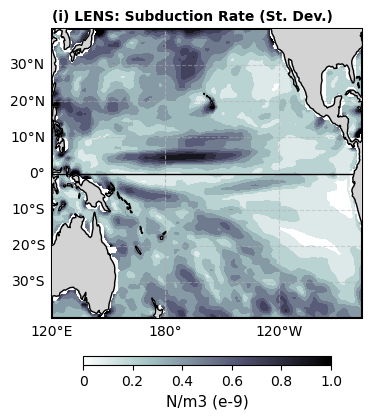

In [72]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_lens_diff.plot.contourf(
    x='lon', y='lat', cmap='bone_r', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=0, vmax=1e-9, levels=11, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='bone_r', norm=plt.Normalize(0, 1.))

density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('N/m3 (e-9)', fontsize=11)
tick_values = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(i) LENS: Subduction Rate (St. Dev.)', fontsize=10, fontweight='bold', zorder=12, loc='left')
plt.ylim(-40, 40)
plt.show()

In [ ]:
variables_xr = xr.Dataset()
taux_np = TAUX_data.values
tauy_np = TAUY_data.values
dx_np = ds_smyle_fosi_var.DXU.values  # or DXT depending on grid
dy_np = ds_smyle_fosi_var.DYU.values  # or DYT depending on grid

# Calculate curl
curl_np = calculate_curl_simple(taux_np, tauy_np, dx_np, dy_np)

# Convert back to xarray
curl_simple = xr.DataArray(
    curl_np,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [ ]:
def calculate_curl_simple(taux, tauy, dx, dy):
    """Calculate curl using centered finite differences"""
    # Assuming all arrays are on the same grid
    # Use numpy gradient
    dtauy_dx = np.gradient(tauy, axis=1) / dx
    dtaux_dy = np.gradient(taux, axis=0) / dy
    return dtauy_dx - dtaux_dy

# Convert to numpy arrays
variables_xr = xr.Dataset()
taux_np = lens_TAUX.values
tauy_np = lens_TAUY.values
dx_np = ds_smyle_fosi_var.DXU.values  # or DXT depending on grid
dy_np = ds_smyle_fosi_var.DYU.values  # or DYT depending on grid

# Calculate curl
curl_np = calculate_curl_simple(taux_np, tauy_np, dx_np, dy_np)

# Convert back to xarray
curl_simple = xr.DataArray(
    curl_np,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [ ]:
# Convert to numpy arrays
variables_xr = xr.Dataset()
taux_np = lens_TAUX.values
tauy_np = lens_TAUY.values
dx_np = ds_smyle_fosi_var.DXU.values  # or DXT depending on grid
dy_np = ds_smyle_fosi_var.DYU.values  # or DYT depending on grid

# Calculate curl
curl_np_lens = calculate_curl_simple(taux_np, tauy_np, dx_np, dy_np)

# Convert back to xarray
curl_np_lens = xr.DataArray(
    curl_np_lens,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [41]:
lens_TAUX = xr.concat(TAUX_lens_list, dim='ensemble').mean(dim='ensemble')

In [42]:
lens_TAUY = xr.concat(TAUY_lens_list, dim='ensemble').mean(dim='ensemble')

In [43]:
# Convert to numpy arrays
variables_xr = xr.Dataset()
taux_np = lens_TAUX.values
tauy_np = lens_TAUY.values
dx_np = ds_smyle_fosi_var.DXU.values  # or DXT depending on grid
dy_np = ds_smyle_fosi_var.DYU.values  # or DYT depending on grid

# Calculate curl
curl_np_lens = calculate_curl_simple(taux_np, tauy_np, dx_np, dy_np)

# Convert back to xarray
curl_np_lens = xr.DataArray(
    curl_np_lens,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [44]:
# Convert back to xarray
curl_np_lens = xr.DataArray(
    curl_np_lens,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [51]:
diff = curl_np_lens - curl_simple


In [52]:
diff = xr.DataArray(
    diff.data,
    coords=TAUX.coords,
    dims=TAUX.dims,
    name='wind_stress_curl_simple'
)

In [53]:
diff_1deg_wzeros_var = regrid_SMYLE(diff)
diff_1deg_var = diff_1deg_wzeros_var.where(diff_1deg_wzeros_var!=0, np.nan)
regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[0,:,:], 'nearest_s2d', periodic=True)
regridded_lens_diff = regridder(diff_1deg_var)
# regridded_fosi_TAUX = regridder(fosi_1deg_var)
# diff = regridded_lens_TAUX - regridded_fosi_TAUX

In [127]:
regridded_lens_TAUX = regridder(lens_1deg_var)
regridded_fosi_TAUX = regridder(fosi_1deg_var)

In [ ]:
diff_1deg_wzeros_var = regrid_SMYLE(curl_np_lens)
diff_1deg_var = diff_1deg_wzeros_var.where(diff_1deg_wzeros_var!=0, np.nan)
regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[0,:,:], 'nearest_s2d', periodic=True)

In [39]:
regridded_lens_curl_simple = regridder(diff_1deg_var)

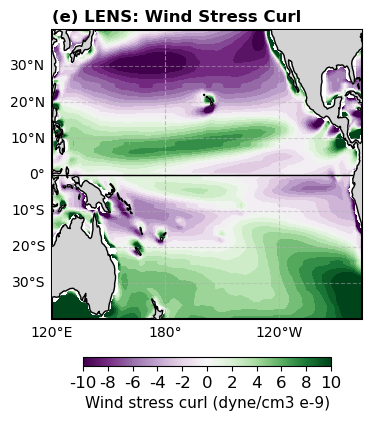

In [40]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
# ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_lens_curl_simple.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-1e-8, vmax=1e-8, levels=21, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-10, 10))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('Wind stress curl (N/m3 e-9)', fontsize=11)
tick_values = np.arange(-10, 12, 2) 
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x:.0f}' for x in tick_values])

# density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=12)

plt.title('(b) LENS: Wind stress curl', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()

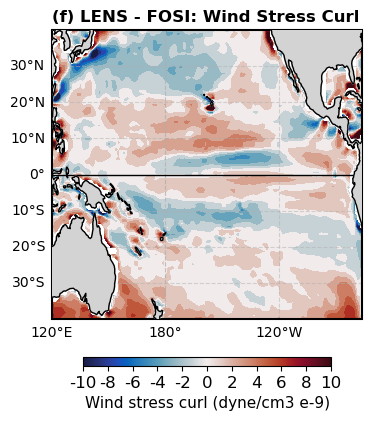

In [50]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
# ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
ax.set_extent([120, 284, -40, 40], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_lens_diff.plot.contourf(
    x='lon', y='lat', cmap=cmocean.cm.balance, add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-1e-8, vmax=1e-8, levels=16, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap=cmocean.cm.balance, norm=plt.Normalize(-10, 10))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label('N/m3 (e-7)', fontsize=11)
tick_values = np.arange(-10, 12, 2) 
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x:.0f}' for x in tick_values])

# density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=12)

plt.title('(d) LENS - FOSI: Wind stress curl', fontsize=12, fontweight='bold', zorder=12, loc='left')
plt.show()